# 1. Business Context

The objective of this notebook is to apply and compare multiple unsupervised learning algorithms to identify meaningful customer segments based on purchasing behavior.
The analysis focuses on discovering hidden customer patterns that can support targeted marketing strategies, customer retention initiatives, and revenue optimization.

In [ ]:
#2. Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

In [28]:
#3. Load Processed Data
rfm_scaled = pd.read_csv(
    "../data/processed/rfm_scaled.csv",
    index_col=0
)

rfm_log = pd.read_csv(
    "../data/processed/rfm_log.csv",
    index_col=0
)

In [4]:
#4. Dataset Inspection
rfm_scaled.head()
rfm_scaled.shape

(5878, 6)

# 5. Dimensionality Reduction using PCA

Principal Component Analysis (PCA) is applied to reduce the dimensionality of the dataset while preserving most of the variance.
This transformation enables visual exploration of customer clusters in a two-dimensional space.

In [5]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

In [6]:
pca_df = pd.DataFrame(
    rfm_pca,
    columns=["PC1", "PC2"]
)

In [7]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.50409242, 0.29092203])

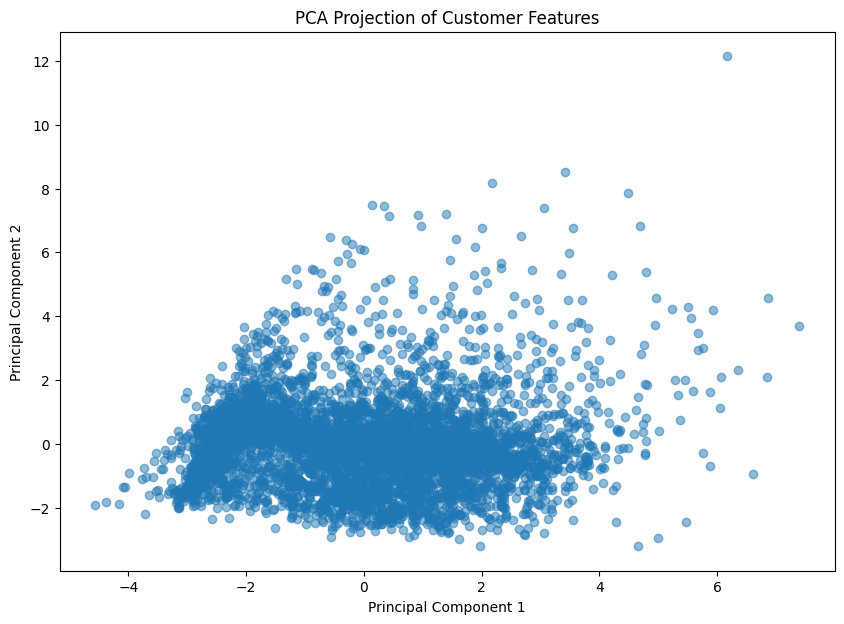

In [8]:
plt.figure(figsize=(10,7))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.5
)

plt.title("PCA Projection of Customer Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [ ]:
#6. KMeans Clustering

#Elbow Method
inertia = []

k_range = range(2,11)

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

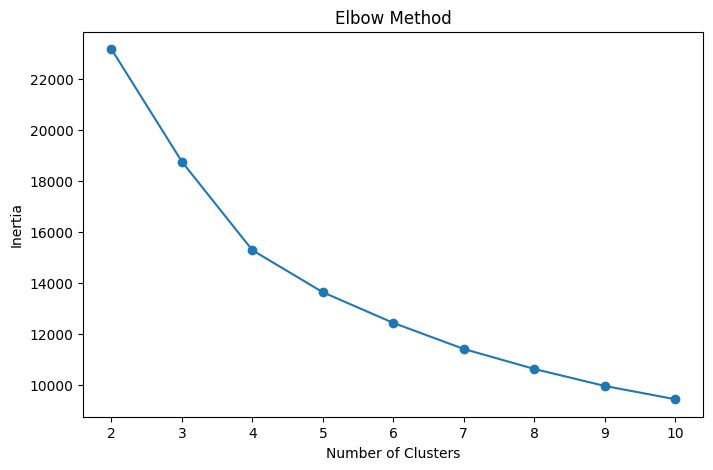

In [10]:
plt.figure(figsize=(8,5))

plt.plot(k_range, inertia, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

In [11]:
#Silhouette Scores
silhouette_scores = []

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

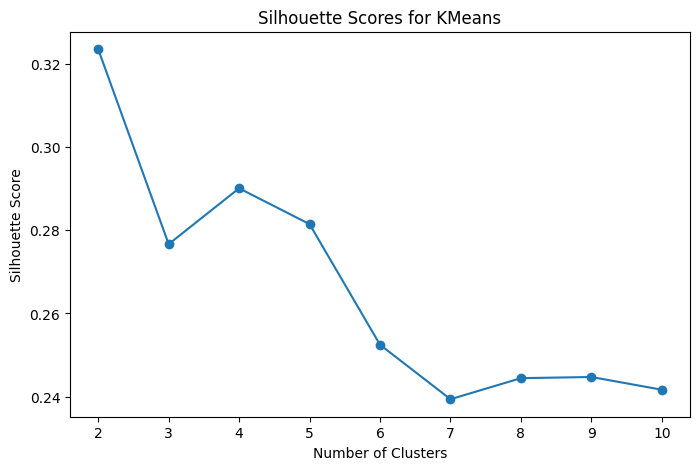

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    k_range,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Scores for KMeans")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [13]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(rfm_scaled)

In [14]:
pca_df["KMeans_Cluster"] = kmeans_labels

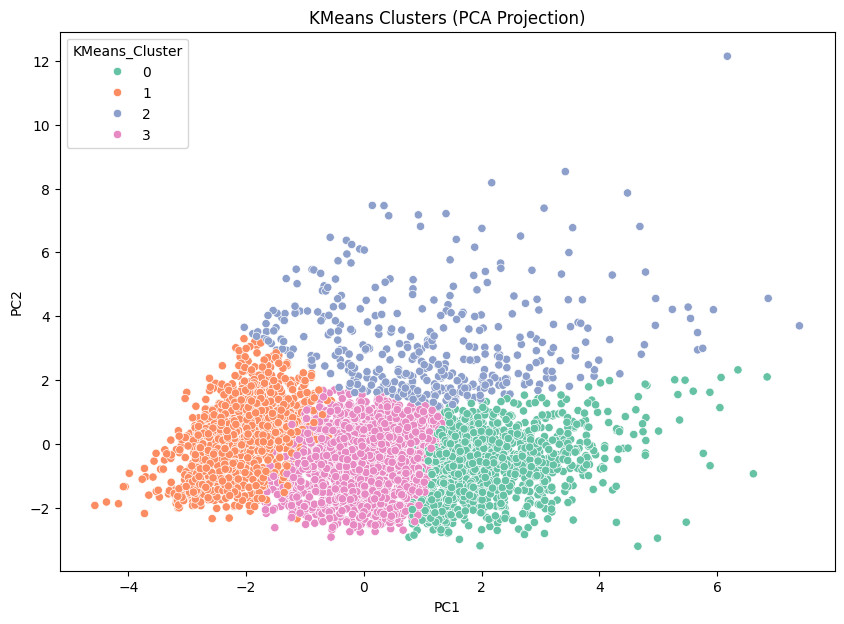

In [15]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="KMeans_Cluster",
    data=pca_df,
    palette="Set2"
)

plt.title("KMeans Clusters (PCA Projection)")

plt.show()

In [ ]:
#7. Agglomerative Clustering
agg_model = AgglomerativeClustering(
    n_clusters=4
)

agg_labels = agg_model.fit_predict(rfm_scaled)

In [18]:
agg_silhouette = silhouette_score(
    rfm_scaled,
    agg_labels
)

agg_calinski = calinski_harabasz_score(
    rfm_scaled,
    agg_labels
)

agg_davies = davies_bouldin_score(
    rfm_scaled,
    agg_labels
)

print(f"Silhouette Score: {agg_silhouette:.4f}")
print(f"Calinski-Harabasz Score: {agg_calinski:.2f}")
print(f"Davies-Bouldin Score: {agg_davies:.4f}")

Silhouette Score: 0.2608
Calinski-Harabasz Score: 1996.74
Davies-Bouldin Score: 1.1306


In [19]:
pca_df["Agglomerative_Cluster"] = agg_labels

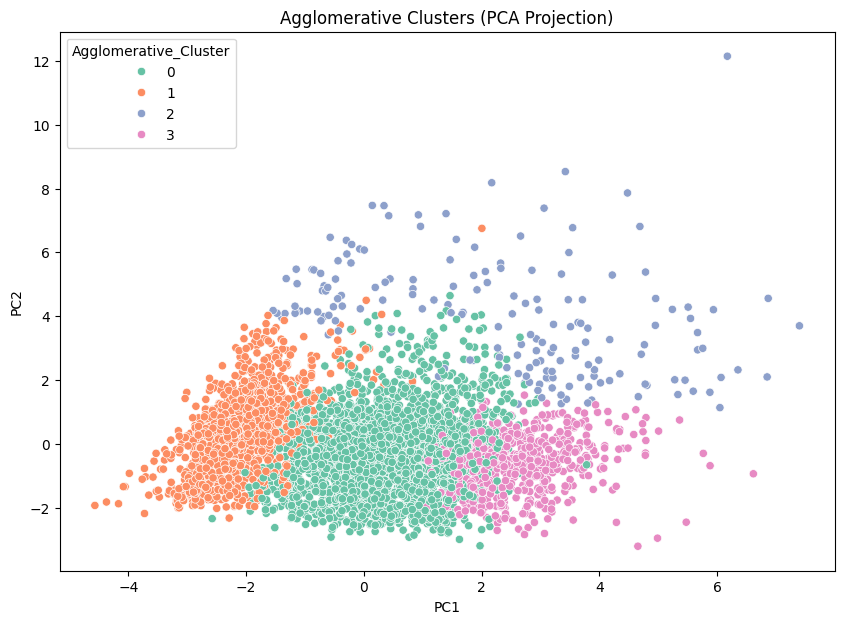

In [20]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Agglomerative_Cluster",
    data=pca_df,
    palette="Set2"
)

plt.title("Agglomerative Clusters (PCA Projection)")

plt.show()

In [ ]:
#8. Gaussian Mixture Model
gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

gmm_labels = gmm.fit_predict(rfm_scaled)

In [22]:
gmm_silhouette = silhouette_score(
    rfm_scaled,
    gmm_labels
)

gmm_calinski = calinski_harabasz_score(
    rfm_scaled,
    gmm_labels
)

gmm_davies = davies_bouldin_score(
    rfm_scaled,
    gmm_labels
)

print(f"Silhouette Score: {gmm_silhouette:.4f}")
print(f"Calinski-Harabasz Score: {gmm_calinski:.2f}")
print(f"Davies-Bouldin Score: {gmm_davies:.4f}")

Silhouette Score: 0.1627
Calinski-Harabasz Score: 1370.29
Davies-Bouldin Score: 1.9552


In [23]:
pca_df["GMM_Cluster"] = gmm_labels

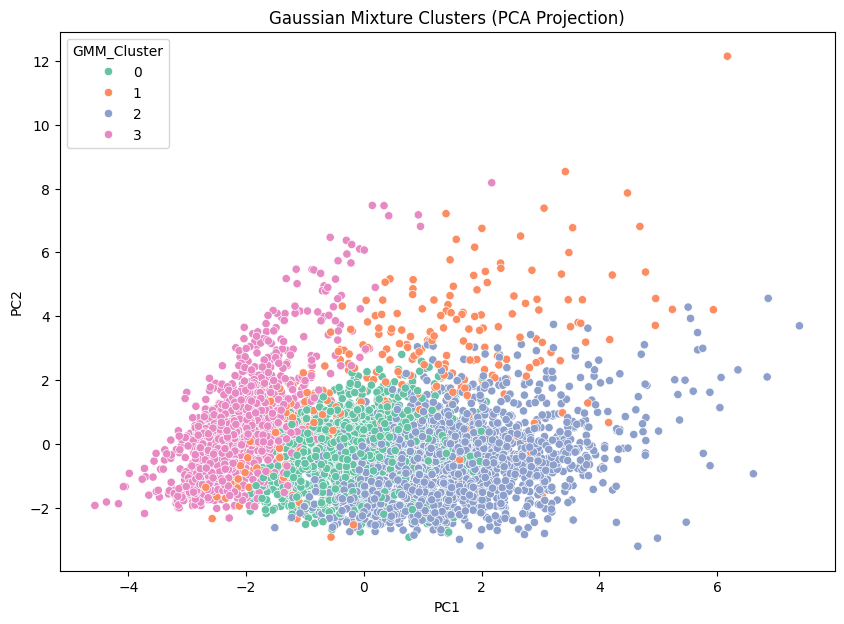

In [24]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="GMM_Cluster",
    data=pca_df,
    palette="Set2"
)

plt.title("Gaussian Mixture Clusters (PCA Projection)")

plt.show()

In [25]:
#9. Model Comparison
model_results = pd.DataFrame({

    "Model": [
        "KMeans",
        "Agglomerative",
        "Gaussian Mixture"
    ],

    "Silhouette Score": [
        silhouette_score(
            rfm_scaled,
            kmeans_labels
        ),

        silhouette_score(
            rfm_scaled,
            agg_labels
        ),

        silhouette_score(
            rfm_scaled,
            gmm_labels
        )
    ],

    "Calinski-Harabasz": [
        calinski_harabasz_score(
            rfm_scaled,
            kmeans_labels
        ),

        calinski_harabasz_score(
            rfm_scaled,
            agg_labels
        ),

        calinski_harabasz_score(
            rfm_scaled,
            gmm_labels
        )
    ],

    "Davies-Bouldin": [

        davies_bouldin_score(
            rfm_scaled,
            kmeans_labels
        ),

        davies_bouldin_score(
            rfm_scaled,
            agg_labels
        ),

        davies_bouldin_score(
            rfm_scaled,
            gmm_labels
        )
    ]
})

In [26]:
model_results

,Model,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,KMeans,0.290116,2560.133805,1.163931
1,Agglomerative,0.260756,1996.736476,1.130575
2,Gaussian Mixture,0.162694,1370.285207,1.955225


In [30]:
#10. Cluster Profiling
rfm_log["Cluster"] = kmeans_labels

cluster_profile = rfm_log.groupby("Cluster").mean()

cluster_profile_exp = np.expm1(cluster_profile)

cluster_profile_exp

,Recency,Frequency,Monetary,AvgOrderValue,BasketSize,CustomerLifetime
Cluster,,,,,,
0,15.529071,12.682357,4579.837250,18.404760,10.204211,504.686679
1,240.535256,1.079603,229.775561,15.362513,7.757162,0.154264
2,101.973973,4.258856,2075.597181,134.945805,76.840172,69.544701
3,102.323315,3.470476,873.887379,14.470708,7.969218,220.737527


In [34]:
rfm_log["Cluster"] = kmeans_labels

cluster_profile = rfm_log.groupby("Cluster").mean()

cluster_profile

cluster_profile_exp = np.expm1(cluster_profile)

cluster_profile_exp.round(2)

,Recency,Frequency,Monetary,AvgOrderValue,BasketSize,CustomerLifetime
Cluster,,,,,,
0,15.53,12.68,4579.84,18.40,10.20,504.69
1,240.54,1.08,229.78,15.36,7.76,0.15
2,101.97,4.26,2075.60,134.95,76.84,69.54
3,102.32,3.47,873.89,14.47,7.97,220.74


In [35]:
rfm_log["Cluster"].value_counts()

Cluster
3    2411
1    1691
0    1372
2     404
Name: count, dtype: int64

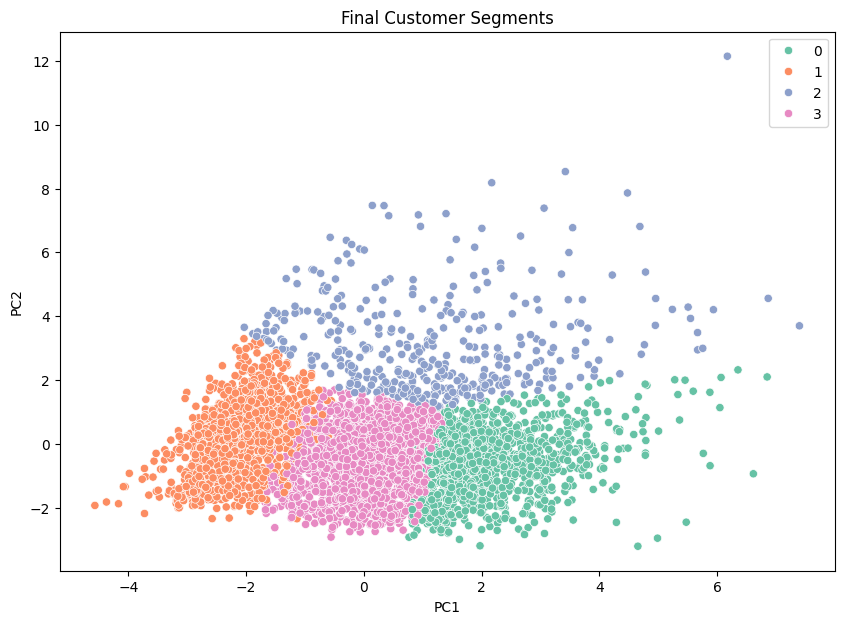

In [36]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue=kmeans_labels,
    data=pca_df,
    palette="Set2"
)

plt.title("Final Customer Segments")

plt.show()

# 11. Cluster Interpretation
The clustering analysis identified four distinct customer segments with clearly differentiated purchasing behaviors.

Cluster 0 represents highly valuable and loyal customers characterized by high purchase frequency, recent activity, and significant monetary contribution. These customers are strong candidates for premium loyalty initiatives and retention strategies.

Cluster 1 contains low-engagement customers with minimal purchase history and long inactivity periods, suggesting a high likelihood of churn. Reactivation campaigns and targeted promotions may help recover part of this segment.

Cluster 2 consists of high-value bulk buyers who generate substantial revenue through large individual purchases. These customers may represent corporate or wholesale purchasing behaviors and could benefit from personalized account management strategies.

Cluster 3 represents regular customers with moderate purchasing activity and stable long-term engagement. This segment forms the operational core of the business and presents opportunities for cross-selling and customer lifetime value optimization.

# 12. Save Final Model

The final clustering model and processed customer segmentation datasets are exported for future reuse and deployment scenarios.

In [46]:
import joblib

joblib.dump(
    kmeans,
    "../models/kmeans_customer_segmentation.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

rfm_log.to_csv(
    "../data/processed/customer_segments.csv"
)